In [129]:
!pip install kaggle

from google.colab import files
files.upload()

!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d risangbaskoro/wlasl-processed --force
!unzip -o -q wlasl-processed.zip

mv: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/risangbaskoro/wlasl-processed
License(s): other
100% 4.82G/4.82G [01:13<00:00, 70.2MB/s]



In [152]:
import cv2
import numpy as np
import json
import os
import tensorflow as tf
import random

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

In [153]:
def extract_frames(video_path):
    cap = cv2.VideoCapture(video_path)
    frames = []

    while len(frames) < MAX_FRAMES:
        ret, frame = cap.read()

        if not ret:
            break

        frame = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
        frames.append(frame)

    cap.release()


    while len(frames) < MAX_FRAMES:
        frames.append(np.zeros((IMG_SIZE, IMG_SIZE, 3)))

    return np.array(frames)

In [154]:
IMG_SIZE = 96
MAX_FRAMES = 20

In [156]:
X = []
y = []

with open('/content/WLASL_v0.3.json') as f:
    data = json.load(f)

selected_words = [
    "go",
    "help",
    "yes",
    "no",
    "like",
    "who",
    "what",
    "now",
    "later",
    "finish"
]

MAX_PER_CLASS = 20

for label, word in enumerate(selected_words):
    print("Processing:", word)


    instances_list = []

    for item in data:
        if item['gloss'] == word:
            instances_list.extend(item['instances'])


    random.shuffle(instances_list)

    valid_count = 0

    for inst in instances_list:
        video_id = inst['video_id']
        path = f"/content/videos/{video_id}.mp4"

        if not os.path.exists(path):
            continue

        frames = extract_frames(path)

        if np.max(frames) == 0:
            continue

        X.append(frames)
        y.append(label)
        valid_count += 1

        if valid_count >= MAX_PER_CLASS:
            break

    print(f"{word}: {valid_count} videos")

X = np.array(X)
y = np.array(y)

print("FINAL SHAPE:", X.shape, y.shape)

Processing: go
go: 15 videos
Processing: help
help: 14 videos
Processing: yes
yes: 12 videos
Processing: no
no: 11 videos
Processing: like
like: 10 videos
Processing: who
who: 14 videos
Processing: what
what: 12 videos
Processing: now
now: 9 videos
Processing: later
later: 12 videos
Processing: finish
finish: 9 videos
FINAL SHAPE: (118, 20, 96, 96, 3) (118,)


In [157]:
from collections import Counter

word_counts = {}

for item in data:
    word = item['gloss']
    count = len(item['instances'])

    word_counts[word] = count


sorted_words = sorted(word_counts.items(), key=lambda x: x[1], reverse=True)

print(sorted_words[:20])

[('book', 40), ('drink', 35), ('computer', 30), ('before', 26), ('chair', 26), ('go', 26), ('clothes', 25), ('who', 25), ('candy', 24), ('cousin', 23), ('deaf', 23), ('fine', 22), ('help', 22), ('no', 22), ('thin', 22), ('walk', 22), ('year', 22), ('yes', 22), ('all', 21), ('black', 21)]


In [158]:
from collections import Counter

print("Label distribution:", Counter(y))

Label distribution: Counter({np.int64(0): 15, np.int64(1): 14, np.int64(5): 14, np.int64(2): 12, np.int64(6): 12, np.int64(8): 12, np.int64(3): 11, np.int64(4): 10, np.int64(7): 9, np.int64(9): 9})


In [159]:
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle

X = X.astype('float32') / 255.0
X, y = shuffle(X, y, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [160]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (118, 20, 96, 96, 3)
y shape: (118,)


In [161]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Dense, TimeDistributed, LSTM, Dropout, BatchNormalization, GlobalAveragePooling2D

model = Sequential([
    TimeDistributed(Conv2D(32, (3,3), activation='relu'),
                    input_shape=(20,96,96,3)),
    TimeDistributed(BatchNormalization()),
    TimeDistributed(MaxPooling2D(2,2)),

    TimeDistributed(Conv2D(64, (3,3), activation='relu')),
    TimeDistributed(MaxPooling2D(2,2)),

    TimeDistributed(GlobalAveragePooling2D()),

    LSTM(64),
    Dropout(0.2),

    Dense(32, activation='relu'),
    Dropout(0.3),

    Dense(len(selected_words), activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/wrapper.py:27: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [162]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))

print("Class Weights:", class_weights)

Class Weights: {0: np.float64(0.7833333333333333), 1: np.float64(0.8545454545454545), 2: np.float64(0.94), 3: np.float64(1.0444444444444445), 4: np.float64(1.175), 5: np.float64(0.8545454545454545), 6: np.float64(0.94), 7: np.float64(1.3428571428571427), 8: np.float64(1.0444444444444445), 9: np.float64(1.3428571428571427)}


In [163]:
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (94, 20, 96, 96, 3)
Test size: (24, 20, 96, 96, 3)


In [164]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=2,
    validation_data=(X_test, y_test),
    callbacks=[early_stop],
)

Epoch 1/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 127s 2s/step - accuracy: 0.0532 - loss: 2.3445 - val_accuracy: 0.1667 - val_loss: 2.2709
Epoch 2/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 108s 2s/step - accuracy: 0.1489 - loss: 2.2991 - val_accuracy: 0.1667 - val_loss: 2.2682
Epoch 3/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 142s 2s/step - accuracy: 0.1383 - loss: 2.2859 - val_accuracy: 0.1667 - val_loss: 2.2652
Epoch 4/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 108s 2s/step - accuracy: 0.1915 - loss: 2.2929 - val_accuracy: 0.1667 - val_loss: 2.2750
Epoch 5/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 150s 2s/step - accuracy: 0.1596 - loss: 2.2709 - val_accuracy: 0.1667 - val_loss: 2.2779
Epoch 6/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 109s 2s/step - accuracy: 0.1489 - loss: 2.3034 - val_accuracy: 0.1250 - val_loss: 2.3113
Epoch 7/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 144s 2s/step - accuracy: 0.1809 - loss: 2.2705 - val_accuracy: 0.1667 - val_loss: 2.3082
Epoch 8/20
47/47 ━━━━━━━━━━━━━━━━━━━━ 136s 2s/step - accuracy: 0.1809 - loss: 2.2106 - val_accuracy: 0.1667 - v

In [165]:
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.1667 - loss: 2.2652
Test Accuracy: 0.1666666716337204


In [166]:
from sklearn.metrics import classification_report
import numpy as np

y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

labels = list(range(len(selected_words)))

print("\nClassification Report:\n")
print(classification_report(
    y_test,
    y_pred_classes,
    labels=labels,
    target_names=selected_words,
    zero_division=0
))

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step

Classification Report:

              precision    recall  f1-score   support

          go       0.20      0.33      0.25         3
        help       0.00      0.00      0.00         3
         yes       0.00      0.00      0.00         2
          no       0.00      0.00      0.00         2
        like       0.00      0.00      0.00         2
         who       0.00      0.00      0.00         3
        what       0.00      0.00      0.00         2
         now       0.00      0.00      0.00         2
       later       0.17      1.00      0.29         3
      finish       0.00      0.00      0.00         2

    accuracy                           0.17        24
   macro avg       0.04      0.13      0.05        24
weighted avg       0.05      0.17      0.07        24



In [167]:
from sklearn.metrics import accuracy_score
import numpy as np

print("\nAccuracy per Class:\n")

for i, word in enumerate(selected_words):
    idx = (y_test == i)

    if np.sum(idx) == 0:
        print(f"{word}: No samples in test set")
        continue

    acc = accuracy_score(y_test[idx], y_pred_classes[idx])
    print(f"{word}: {acc:.2f}")


Accuracy per Class:

go: 0.33
help: 0.00
yes: 0.00
no: 0.00
like: 0.00
who: 0.00
what: 0.00
now: 0.00
later: 1.00
finish: 0.00


In [168]:
import glob


json_files = glob.glob("/content/**/*.json", recursive=True)

print(json_files)

['/content/nslt_2000.json', '/content/nslt_300.json', '/content/WLASL_v0.3.json', '/content/nslt_1000.json', '/content/nslt_100.json', '/content/sample_data/anscombe.json']


In [169]:
import json


json_path = "/content/WLASL_v0.3.json"

with open(json_path, "r") as f:
    data = json.load(f)

print("Loaded", len(data), "entries")

Loaded 2000 entries


In [170]:
import time

# take one sample
sample = X_test[0:1]

# warm-up (important)
model.predict(sample)

# measure time
start_time = time.time()
model.predict(sample)
end_time = time.time()

inference_time = end_time - start_time

print(f"Inference Time (1 sample): {inference_time:.6f} seconds")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 112ms/step
Inference Time (1 sample): 0.207737 seconds


In [171]:
from IPython.display import Video, display
import os

def text_to_video(text):
    text = text.lower().strip()

    for item in data:


        if item['gloss'].lower() == text:

            for inst in item['instances']:

                video_id = inst['video_id']

                path = f"/content/videos/{video_id}.mp4"

                print("Checking:", path)

                if os.path.exists(path) and os.path.getsize(path) > 0:
                    return path

    print("Word or video not found")
    return None


user_input = input("Enter a word: ")

video_path = text_to_video(user_input)

if video_path:
    display(Video(video_path, embed=True))

Enter a word: go
Checking: /content/videos/24857.mp4
Checking: /content/videos/69345.mp4


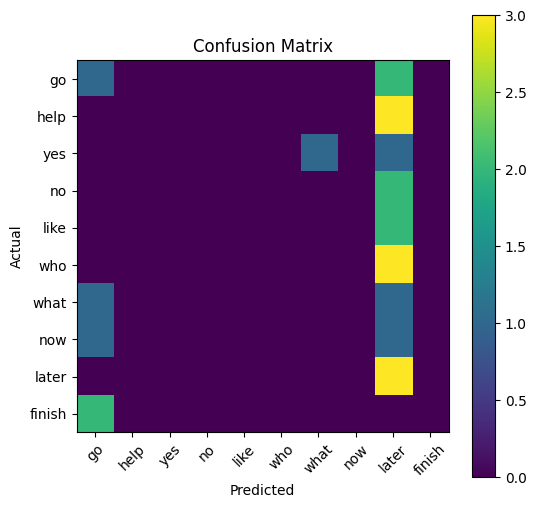

In [172]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(6,6))
plt.imshow(cm, interpolation='nearest')
plt.title("Confusion Matrix")
plt.colorbar()

tick_marks = np.arange(len(selected_words))
plt.xticks(tick_marks, selected_words, rotation=45)
plt.yticks(tick_marks, selected_words)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

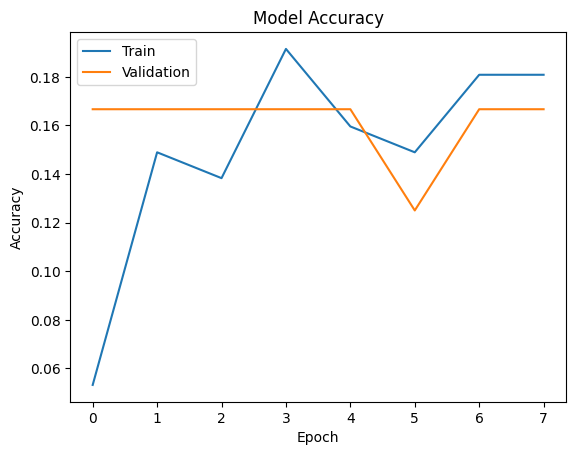

In [173]:
# Training vs Validation Accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])
plt.show()

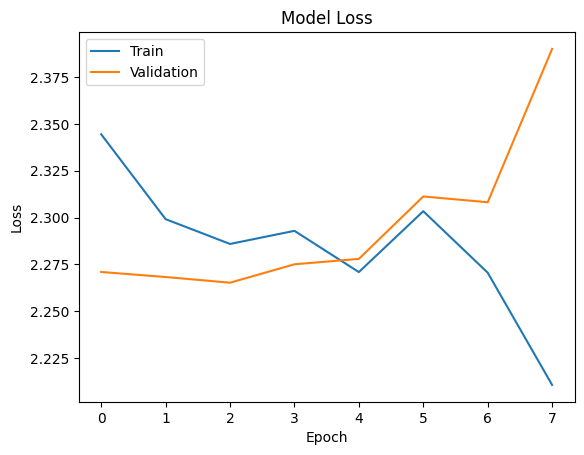

In [174]:
# Training vs Validation Loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')

plt.legend(['Train', 'Validation'])
plt.show()